# Phase 4: Anomaly and Outlier Detection — Revised

PIC: Data Engineer + Pattern Analyst

Notebook ini adalah versi revisi dari Phase 4. Logika teknis utama tetap sama: IQR, Z-Score, Isolation Forest, dan cross-reference dengan outlier BIRCH+HDBSCAN dari Phase 2. Revisi utama ada pada lapisan interpretasi: weighted risk score, risk level, anomaly type, anomaly reason, investigation category, confusion matrix, dan summary table untuk Phase 5.

Perubahan penting:
- risk_score sekarang berbobot: IQR=1, Z-Score=1, Isolation Forest=2, BIRCH+HDBSCAN=2.
- risk_level membagi transaksi menjadi Normal, Low, Medium, High, dan Critical.
- anomaly_type, anomaly_reason, dan investigation_category ditambahkan agar setiap anomali punya alasan investigasi.
- Validasi fraud dilengkapi confusion matrix, precision, recall, dan F1.
- Output export berisi kolom interpretatif untuk dashboard/laporan Phase 5.

In [18]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

SIGNAL_WEIGHTS = {
    "flag_IQR": 1,
    "flag_ZScore": 1,
    "flag_IsoForest": 2,
    "flag_HDBSCAN": 2,
}
HIGH_RISK_THRESHOLD = 3
CRITICAL_RISK_THRESHOLD = 5

## 1. Load Data

Data yang digunakan berasal dari Phase 2:
- paysim-dataset-phase2.parquet: dataset lengkap yang sudah berisi hasil clustering.
- paysim-outliers-phase4.parquet: subset outlier dari kombinasi BIRCH+HDBSCAN.

Catatan penting: kolom numerik seperti amount, origError, dan destError sudah berada dalam bentuk hasil scaling dari phase sebelumnya.

In [19]:
path_1 = "../datasets/phase_2/paysim-dataset-phase2.parquet"
path_2 = "../datasets/phase_2/paysim-outliers-phase4.parquet"

df = pd.read_parquet(path_1)
df_outliers = pd.read_parquet(path_2)

print(f"Data shape          : {df.shape}")
print(f"Data outliers shape : {df_outliers.shape}")
print(f"Columns             : {list(df.columns)}")

df.head()

Data shape          : (6362604, 18)
Data outliers shape : (3923, 18)
Columns             : ['step', 'amount', 'oldbalanceOrg', 'oldbalanceDest', 'isFraud', 'origError', 'destError', 'isDestMerchant', 'origDrainedToZero', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER', 'cluster_kmeans', 'cluster_hdbscan', 'cluster_birch', 'cluster_birch_hdbscan']


,step,amount,oldbalanceOrg,oldbalanceDest,isFraud,origError,destError,isDestMerchant,origDrainedToZero,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,cluster_kmeans,cluster_hdbscan,cluster_birch,cluster_birch_hdbscan
0,1,-0.332937,1.452975,-0.140722,0,-0.278402,0.108607,1,0,0,0,0,1,0,1,-1,2,3
1,1,-0.373767,0.065605,-0.140722,0,-0.278402,-0.075063,1,0,0,0,0,1,0,1,3,2,3
2,1,-0.382384,-0.130713,-0.140722,1,-0.278402,-0.113829,0,1,0,0,0,0,1,1,-1,2,3
3,1,-0.382384,-0.130713,-0.118260,1,-0.278402,0.373988,0,1,0,1,0,0,0,1,-1,2,3
4,1,-0.323576,0.254812,-0.140722,0,-0.278402,0.150717,1,0,0,0,0,1,0,1,-1,2,3


In [31]:
# Sanity check: memastikan file outlier Phase 4 konsisten dengan label cluster_birch_hdbscan == -1.
expected_outlier_count = (df["cluster_birch_hdbscan"] == -1).sum()
print(f"Row with cluster_birch_hdbscan == -1 in df : {expected_outlier_count:,}")
print(f"Row in paysim-outliers-phase4.parquet        : {len(df_outliers):,}")
print("Consistent" if expected_outlier_count == len(df_outliers) else "Inconsistent - recheck export from Phase 2")

Row with cluster_birch_hdbscan == -1 in df : 3,923
Row in paysim-outliers-phase4.parquet        : 3,923
Consistent


## 2. Statistical Anomaly Detection — IQR Method

IQR menandai transaksi sebagai anomali ketika amount berada di luar rentang Q1 - 1.5×IQR sampai Q3 + 1.5×IQR. Karena amount sudah diskalakan, hasil ini dibaca sebagai nilai yang ekstrem relatif terhadap distribusi transaksi pada dataset.

In [21]:
def detect_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    flag = ((df[column] < lower) | (df[column] > upper)).astype(int)

    print(f"IQR Detection - {column}")
    print(f"Q1: {Q1:.4f}  |  Q3: {Q3:.4f}  |  IQR: {IQR:.4f}")
    print(f"Lower bound: {lower:.4f}  |  Upper bound: {upper:.4f}")
    print(f"Total anomalies: {flag.sum():,} ({flag.mean()*100:.2f}%)")

    extreme_values = df.loc[flag == 1, column]
    if not extreme_values.empty:
        print(f"Max anomaly value: {extreme_values.max():.2f}  |  Min anomaly value: {extreme_values.min():.2f}")

    return flag

iqr_flag = detect_iqr(df, "amount")

IQR Detection - amount
Q1: -0.3148  |  Q3: 0.6852  |  IQR: 1.0000
Lower bound: -1.8148  |  Upper bound: 2.1852
Total anomalies: 338,077 (5.31%)
Max anomaly value: 472.89  |  Min anomaly value: 2.19


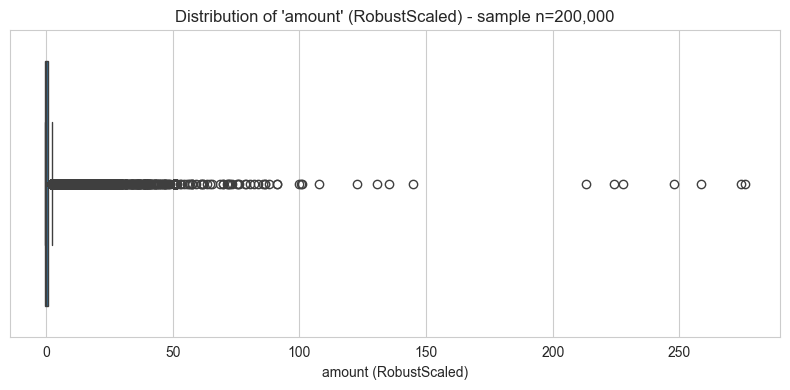

In [32]:
sample = df.sample(min(len(df), 200_000), random_state=42)

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x=sample["amount"], ax=ax)
ax.set_title(f"Distribution of 'amount' (RobustScaled) - sample n={len(sample):,}")
ax.set_xlabel("amount (RobustScaled)")
plt.tight_layout()
plt.show()

## 3. Statistical Anomaly Detection — Z-Score Method

Z-Score menandai transaksi ketika nilai amount berada lebih dari 3 standar deviasi dari rata-rata. Metode ini lebih ketat daripada IQR pada data yang sangat skewed, sehingga biasanya menangkap transaksi yang lebih ekstrem.

In [23]:
def detect_zscore(df, column, threshold=3):
    mean = df[column].mean()
    std = df[column].std()

    z = (df[column] - mean) / std
    flag = (np.abs(z) > threshold).astype(int)

    print(f"Z-Score Detection - {column}")
    print(f"Mean: {mean:.4f}  |  Std Dev: {std:.4f}  |  Threshold: |Z| > {threshold}")
    print(f"Total anomalies: {flag.sum():,} ({flag.mean()*100:.2f}%)")

    extreme_values = df.loc[flag == 1, column]
    if not extreme_values.empty:
        print(f"Max anomaly value: {extreme_values.max():.2f}  |  Min anomaly value: {extreme_values.min():.2f}")

    return flag

z_flag = detect_zscore(df, "amount")

Z-Score Detection - amount
Mean: 0.5375  |  Std Dev: 3.0914  |  Threshold: |Z| > 3
Total anomalies: 44,945 (0.71%)
Max anomaly value: 472.89  |  Min anomaly value: 9.81


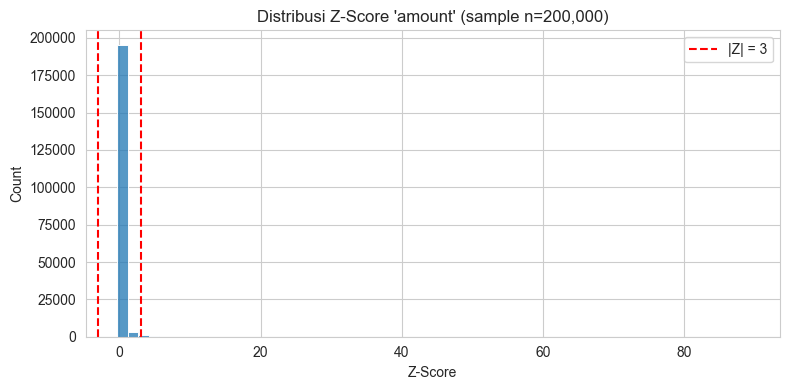

In [24]:
sample_z = (sample["amount"] - df["amount"].mean()) / df["amount"].std()

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(sample_z, bins=60, ax=ax)
ax.axvline(3, color="red", linestyle="--", label="|Z| = 3")
ax.axvline(-3, color="red", linestyle="--")
ax.set_title(f"Distribusi Z-Score 'amount' (sample n={len(sample):,})")
ax.set_xlabel("Z-Score")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Gabungan IQR + Z-Score

Bagian ini hanya melihat overlap metode univariate sebelum hasilnya digabung dengan Isolation Forest dan cluster outlier.

In [33]:
def combine_flags(iqr_flag, z_flag):
    combined = iqr_flag + z_flag
    print(f"Total univariate anomaly (>=1 metode) : {(combined >= 1).sum():,}")
    print(f"IQR and Z-Score (>=2)         : {(combined >= 2).sum():,}")
    return combined

combined_uni = combine_flags(iqr_flag, z_flag)

Total univariate anomaly (>=1 metode) : 338,077
IQR and Z-Score (>=2)         : 44,945


## 5. Multivariate Anomaly Detection — Isolation Forest

Isolation Forest digunakan untuk mendeteksi anomali berdasarkan kombinasi amount, origError, dan destError. Ini lebih kuat daripada IQR/Z-Score karena tidak hanya membaca nominal transaksi, tetapi juga pola perubahan saldo asal dan tujuan.

In [34]:
def detect_isolation_forest(df, feature_cols=("amount", "origError", "destError"), contamination=0.01):
    feature_cols = list(feature_cols)
    features = df[feature_cols].fillna(0)

    model = IsolationForest(contamination=contamination, random_state=42)
    preds = model.fit_predict(features)
    flag = pd.Series((preds == -1).astype(int), index=df.index, name="flag_IsoForest")

    print("Isolation Forest Detection")
    print(f"Features used   : {', '.join(feature_cols)}")
    print(f"Contamination   : {contamination}")
    print(f"Total anomalies : {flag.sum():,} ({flag.mean()*100:.2f}%)")

    anomaly_data = df.loc[flag == 1, feature_cols]
    if not anomaly_data.empty:
        for col in feature_cols:
            print(f"  Max {col} anomaly : {anomaly_data[col].max():.2f}  |  Min {col} anomaly : {anomaly_data[col].min():.2f}")

    return flag

iso_flag = detect_isolation_forest(df)

Isolation Forest Detection
Features used   : amount, origError, destError
Contamination   : 0.01
Total anomalies : 63,616 (1.00%)
  Max amount anomaly : 472.89  |  Min amount anomaly : 1.01
  Max origError anomaly : 374.47  |  Min origError anomaly : -0.28
  Max destError anomaly : 1747.51  |  Min destError anomaly : -0.12


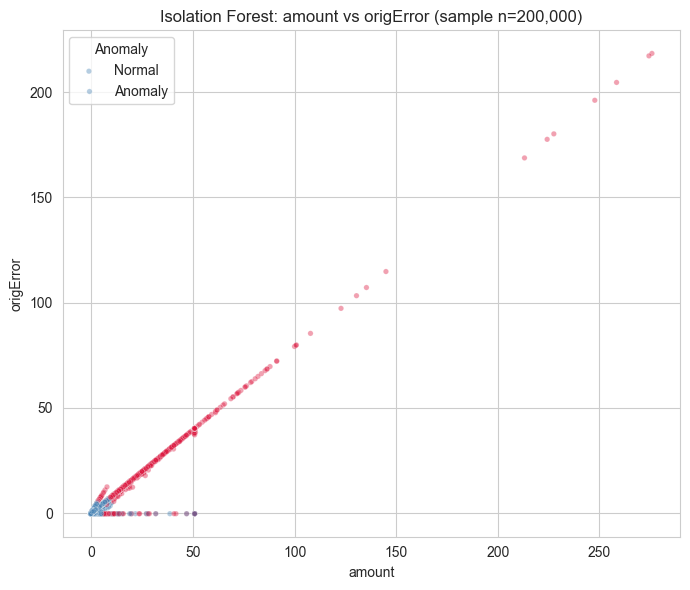

In [35]:
sample_idx = sample.index
sample_plot = df.loc[sample_idx, ["amount", "origError", "destError"]].copy()
sample_plot["iso_flag"] = iso_flag.loc[sample_idx]

fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(
    data=sample_plot,
    x="amount", y="origError",
    hue="iso_flag", palette={0: "steelblue", 1: "crimson"},
    alpha=0.4, s=15, ax=ax
)
ax.set_title(f"Isolation Forest: amount vs origError (sample n={len(sample_plot):,})")
ax.legend(title="Anomaly", labels=["Normal", "Anomaly"])
plt.tight_layout()
plt.show()

## 6. Balance Mismatch Flag untuk Investigasi

Requirement meminta investigasi anomali sebagai kemungkinan data error, rare legitimate case, atau potential fraud. Untuk mendukung itu, dibuat flag tambahan flag_BalanceMismatch dari kolom origError dan destError. Flag ini tidak dimasukkan ke weighted risk score utama, tetapi dipakai untuk menjelaskan alasan dan kategori investigasi.

In [36]:
def detect_balance_mismatch(df, columns=("origError", "destError")):
    flags = []
    bounds = {}

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        col_flag = ((df[col] < lower) | (df[col] > upper)).astype(int)
        flags.append(col_flag)
        bounds[col] = {"lower": lower, "upper": upper, "count": int(col_flag.sum())}

    balance_flag = pd.concat(flags, axis=1).max(axis=1).astype(int)

    print("Balance Mismatch Investigation Flag")
    print(f"Total balance mismatch : {balance_flag.sum():,} ({balance_flag.mean()*100:.2f}%)")
    print("Bounds:")
    for col, val in bounds.items():
        print(f"  {col}: lower={val['lower']:.4f}, upper={val['upper']:.4f}, flagged={val['count']:,}")

    return balance_flag, bounds

balance_flag, balance_bounds = detect_balance_mismatch(df)

Balance Mismatch Investigation Flag
Total balance mismatch : 1,483,549 (23.32%)
Bounds:
  origError: lower=-1.7664, upper=2.2336, flagged=408,487
  destError: lower=-1.6180, upper=2.3820, flagged=1,286,173


## 7. Cross-Reference, Weighted Risk Score, dan Interpretasi Bisnis

Skor risiko direvisi menjadi berbobot:

| Sinyal | Bobot | Alasan |
|---|---:|---|
| IQR | 1 | Metode univariate pada amount |
| Z-Score | 1 | Metode univariate yang lebih ketat |
| Isolation Forest | 2 | Deteksi multivariate pada amount, origError, destError |
| BIRCH+HDBSCAN outlier | 2 | Validasi pola dari cluster/outlier Phase 2 |

Dengan bobot ini, risk_score berada pada rentang 0–6. high_risk ditetapkan ketika risk_score >= 3, sedangkan critical_risk ketika risk_score >= 5.

In [37]:
def build_reason_lookup():
    lookup = {}
    for mask in range(64):
        reasons = []
        if mask & 1:
            reasons.append("High amount anomaly by IQR")
        if mask & 2:
            reasons.append("Extreme amount anomaly by Z-Score")
        if mask & 4:
            reasons.append("Multivariate anomaly by Isolation Forest")
        if mask & 8:
            reasons.append("Cluster outlier from BIRCH+HDBSCAN")
        if mask & 16:
            reasons.append("Extreme balance mismatch in origError/destError")
        if mask & 32:
            reasons.append("Origin account drained to zero")
        lookup[mask] = "; ".join(reasons) if reasons else "No anomaly detected"
    return lookup


def cross_reference(df, iqr_flag, z_flag, iso_flag, balance_flag):
    df = df.copy()
    df["flag_IQR"] = pd.Series(iqr_flag, index=df.index).astype(int)
    df["flag_ZScore"] = pd.Series(z_flag, index=df.index).astype(int)
    df["flag_IsoForest"] = pd.Series(iso_flag, index=df.index).astype(int)
    df["flag_BalanceMismatch"] = pd.Series(balance_flag, index=df.index).astype(int)

    # Menggunakan cluster_birch_hdbscan, bukan cluster_hdbscan langsung, karena HDBSCAN langsung
    # menandai mayoritas data sebagai noise sehingga kurang informatif untuk risk scoring.
    df["flag_HDBSCAN"] = (df["cluster_birch_hdbscan"] == -1).astype(int)

    flag_cols = ["flag_IQR", "flag_ZScore", "flag_IsoForest", "flag_HDBSCAN"]
    df["risk_indicator_count"] = df[flag_cols].sum(axis=1).astype(int)
    df["risk_score"] = (
        df["flag_IQR"] * SIGNAL_WEIGHTS["flag_IQR"] +
        df["flag_ZScore"] * SIGNAL_WEIGHTS["flag_ZScore"] +
        df["flag_IsoForest"] * SIGNAL_WEIGHTS["flag_IsoForest"] +
        df["flag_HDBSCAN"] * SIGNAL_WEIGHTS["flag_HDBSCAN"]
    ).astype(int)

    df["high_risk"] = (df["risk_score"] >= HIGH_RISK_THRESHOLD).astype(int)
    df["critical_risk"] = (df["risk_score"] >= CRITICAL_RISK_THRESHOLD).astype(int)

    df["risk_level"] = pd.Categorical(
        np.select(
            [df["risk_score"] >= CRITICAL_RISK_THRESHOLD, df["risk_score"] >= HIGH_RISK_THRESHOLD, df["risk_score"] == 2, df["risk_score"] == 1],
            ["Critical", "High", "Medium", "Low"],
            default="Normal"
        ),
        categories=["Normal", "Low", "Medium", "High", "Critical"],
        ordered=True
    )

    df["anomaly_type"] = pd.Categorical(
        np.select(
            [
                df["risk_indicator_count"] >= 3,
                (df["flag_IsoForest"] == 1) & (df["flag_HDBSCAN"] == 1),
                df["flag_BalanceMismatch"] == 1,
                df["flag_IsoForest"] == 1,
                df["flag_HDBSCAN"] == 1,
                (df["flag_IQR"] == 1) | (df["flag_ZScore"] == 1),
            ],
            [
                "Multiple Indicators",
                "Behavioral and Cluster Outlier",
                "Balance Mismatch",
                "Behavioral Outlier",
                "Cluster Outlier",
                "Extreme Transaction Amount",
            ],
            default="No Statistical Anomaly"
        )
    )

    df["investigation_category"] = pd.Categorical(
        np.select(
            [
                ((df["isFraud"] == 1) & (df["high_risk"] == 1)) | (df["risk_score"] >= CRITICAL_RISK_THRESHOLD),
                (df["flag_BalanceMismatch"] == 1) & (df["isFraud"] == 0),
                (df["isFraud"] == 0) & (df["high_risk"] == 1),
                df["risk_indicator_count"] >= 1,
            ],
            [
                "Potential Fraud",
                "Possible Data Quality Issue",
                "Rare Legitimate Transaction",
                "Potential Risk / Monitor",
            ],
            default="Normal / Low Concern"
        )
    )

    drained_flag = df["origDrainedToZero"].astype(int) if "origDrainedToZero" in df.columns else 0
    reason_mask = (
        df["flag_IQR"] * 1 +
        df["flag_ZScore"] * 2 +
        df["flag_IsoForest"] * 4 +
        df["flag_HDBSCAN"] * 8 +
        df["flag_BalanceMismatch"] * 16 +
        drained_flag * 32
    ).astype(int)
    df["anomaly_reason"] = pd.Categorical(reason_mask.map(build_reason_lookup()))

    print("Cross Reference Detection with Business Interpretation")
    print(f"Total transactions       : {len(df):,}")
    print(f"IQR anomalies            : {df['flag_IQR'].sum():,}")
    print(f"Z-Score anomalies        : {df['flag_ZScore'].sum():,}")
    print(f"Isolation Forest         : {df['flag_IsoForest'].sum():,}")
    print(f"BIRCH+HDBSCAN outliers   : {df['flag_HDBSCAN'].sum():,}")
    print(f"Balance mismatch flag    : {df['flag_BalanceMismatch'].sum():,}")
    print(f"High risk transactions   : {df['high_risk'].sum():,} ({df['high_risk'].mean()*100:.2f}%)")
    print(f"Critical transactions    : {df['critical_risk'].sum():,} ({df['critical_risk'].mean()*100:.2f}%)")
    print("Weighted risk score distribution:")
    print(df["risk_score"].value_counts().sort_index())
    print("Risk level distribution:")
    print(df["risk_level"].value_counts().sort_index())

    return df

df = cross_reference(df, iqr_flag, z_flag, iso_flag, balance_flag)

Cross Reference Detection with Business Interpretation
Total transactions       : 6,362,604
IQR anomalies            : 338,077
Z-Score anomalies        : 44,945
Isolation Forest         : 63,616
BIRCH+HDBSCAN outliers   : 3,923
Balance mismatch flag    : 1,483,549
High risk transactions   : 63,717 (1.00%)
Critical transactions    : 2,941 (0.05%)
Weighted risk score distribution:
risk_score
0    6023646
1     273596
2       1645
3      19444
4      41332
5         92
6       2849
Name: count, dtype: int64
Risk level distribution:
risk_level
Normal      6023646
Low          273596
Medium         1645
High          60776
Critical       2941
Name: count, dtype: int64


## 8. Ringkasan Anomaly Typology dan Investigation Category

Bagian ini menjawab kekurangan utama dari review: setiap anomali tidak hanya diberi skor, tetapi juga diberi jenis anomali, kategori investigasi, dan alasan yang bisa dibaca manusia.

In [38]:
risk_summary = (
    df["risk_level"].value_counts().sort_index().rename_axis("risk_level").reset_index(name="transactions")
)
risk_summary["percentage"] = risk_summary["transactions"] / len(df) * 100

anomaly_type_summary = (
    df["anomaly_type"].value_counts().rename_axis("anomaly_type").reset_index(name="transactions")
)
anomaly_type_summary["percentage"] = anomaly_type_summary["transactions"] / len(df) * 100

investigation_summary = (
    df["investigation_category"].value_counts().rename_axis("investigation_category").reset_index(name="transactions")
)
investigation_summary["percentage"] = investigation_summary["transactions"] / len(df) * 100

print("Risk Summary")
display(risk_summary)
print("Anomaly Type Summary")
display(anomaly_type_summary)
print("Investigation Category Summary")
display(investigation_summary)

Risk Summary


,risk_level,transactions,percentage
0,Normal,6023646,94.672653
1,Low,273596,4.300063
2,Medium,1645,0.025854
3,High,60776,0.955206
4,Critical,2941,0.046223


Anomaly Type Summary


,anomaly_type,transactions,percentage
0,No Statistical Anomaly,4793091,75.332222
1,Balance Mismatch,1439370,22.622341
2,Extreme Transaction Amount,85685,1.346697
3,Multiple Indicators,44265,0.695706
4,Cluster Outlier,185,0.002908
5,Behavioral and Cluster Outlier,8,0.000126


Investigation Category Summary


,investigation_category,transactions,percentage
0,Normal / Low Concern,4794398,75.352764
1,Possible Data Quality Issue,1477915,23.228147
2,Potential Risk / Monitor,86508,1.359632
3,Potential Fraud,3780,0.059410
4,Rare Legitimate Transaction,3,0.000047


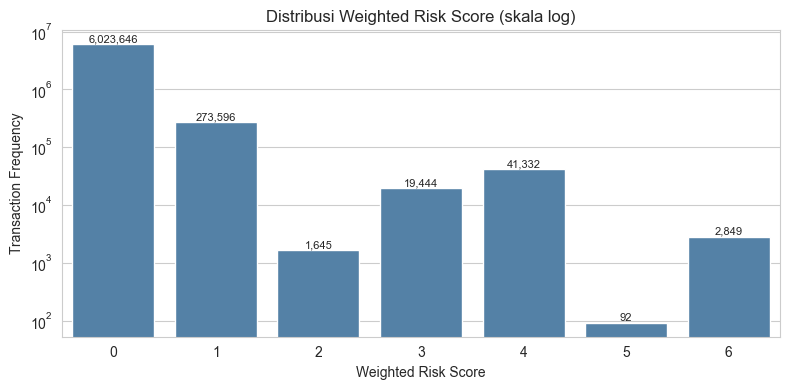

In [39]:
fig, ax = plt.subplots(figsize=(8, 4))
risk_counts = df["risk_score"].value_counts().sort_index()
sns.barplot(x=risk_counts.index, y=risk_counts.values, ax=ax, color="steelblue")
ax.set_xlabel("Weighted Risk Score")
ax.set_ylabel("Transaction Frequency")
ax.set_yscale("log")
ax.set_title("Distribusi Weighted Risk Score (skala log)")
for i, v in enumerate(risk_counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

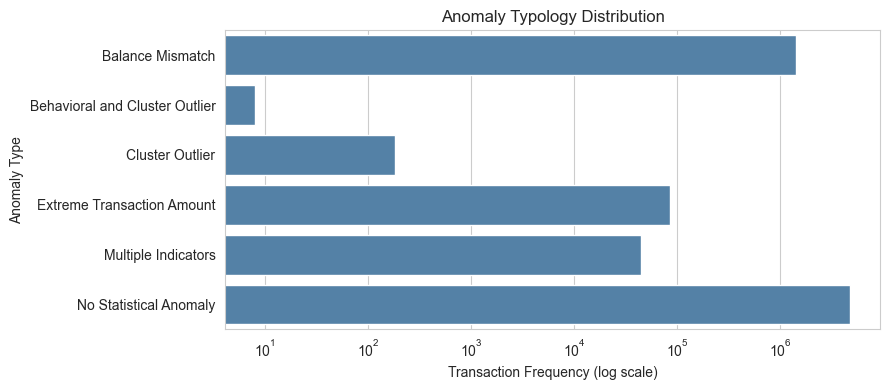

In [41]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(
    data=anomaly_type_summary,
    y="anomaly_type",
    x="transactions",
    ax=ax,
    color="steelblue"
)
ax.set_xscale("log")
ax.set_xlabel("Transaction Frequency (log scale)")
ax.set_ylabel("Anomaly Type")
ax.set_title("Anomaly Typology Distribution")
plt.tight_layout()
plt.show()

## 9. Fraud Validation dan Confusion Matrix

Karena dataset memiliki label isFraud, hasil anomaly detection dapat dievaluasi. Ini bukan supervised model training, tetapi validasi apakah transaksi berisiko tinggi benar-benar memperkaya proporsi fraud dibanding baseline.

In [42]:
def validate_fraud(df):
    y_true = df["isFraud"].astype(int)
    y_pred = df["high_risk"].astype(int)

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())

    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0

    overall_fraud_rate = y_true.mean()
    high_risk_fraud_rate = df.loc[df["high_risk"] == 1, "isFraud"].mean()
    enrichment = high_risk_fraud_rate / overall_fraud_rate if overall_fraud_rate else 0

    metrics = pd.DataFrame([
        {"metric": "TP", "value": tp},
        {"metric": "FP", "value": fp},
        {"metric": "FN", "value": fn},
        {"metric": "TN", "value": tn},
        {"metric": "Precision", "value": precision},
        {"metric": "Recall", "value": recall},
        {"metric": "F1", "value": f1},
        {"metric": "Overall Fraud Rate", "value": overall_fraud_rate},
        {"metric": "High Risk Fraud Rate", "value": high_risk_fraud_rate},
        {"metric": "Fraud Enrichment", "value": enrichment},
    ])

    print("Fraud Validation")
    print(f"High risk transactions : {df['high_risk'].sum():,}")
    print(f"TP={tp:,} | FP={fp:,} | FN={fn:,} | TN={tn:,}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1        : {f1:.4f}")
    print(f"High risk fraud rate : {high_risk_fraud_rate*100:.2f}%")
    print(f"Enrichment           : {enrichment:.1f}x baseline")

    return metrics

fraud_metrics = validate_fraud(df)
fraud_metrics

Fraud Validation
High risk transactions : 63,717
TP=1,429 | FP=62,288 | FN=6,768 | TN=6,292,119
Precision : 0.0224
Recall    : 0.1743
F1        : 0.0397
High risk fraud rate : 2.24%
Enrichment           : 17.4x baseline


,metric,value
0,TP,1.429000e+03
1,FP,6.228800e+04
2,FN,6.768000e+03
3,TN,6.292119e+06
4,Precision,2.242730e-02
5,Recall,1.743321e-01
6,F1,3.974191e-02
7,Overall Fraud Rate,1.288309e-03
8,High Risk Fraud Rate,2.242730e-02
9,Fraud Enrichment,1.740832e+01


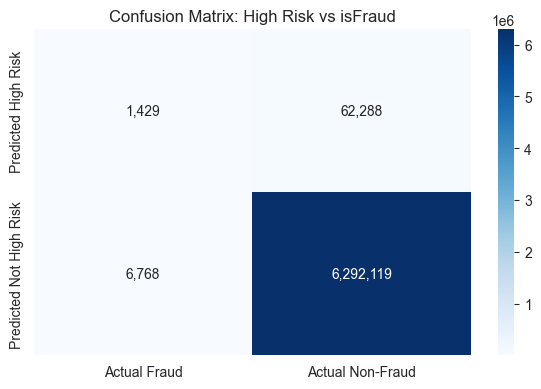

,Actual Fraud,Actual Non-Fraud
Predicted High Risk,1429,62288
Predicted Not High Risk,6768,6292119


In [43]:
conf_matrix = pd.DataFrame(
    [[
        int(((df["isFraud"] == 1) & (df["high_risk"] == 1)).sum()),
        int(((df["isFraud"] == 0) & (df["high_risk"] == 1)).sum()),
    ], [
        int(((df["isFraud"] == 1) & (df["high_risk"] == 0)).sum()),
        int(((df["isFraud"] == 0) & (df["high_risk"] == 0)).sum()),
    ]],
    index=["Predicted High Risk", "Predicted Not High Risk"],
    columns=["Actual Fraud", "Actual Non-Fraud"]
)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt=",d", cmap="Blues", ax=ax)
ax.set_title("Confusion Matrix: High Risk vs isFraud")
plt.tight_layout()
plt.show()

conf_matrix

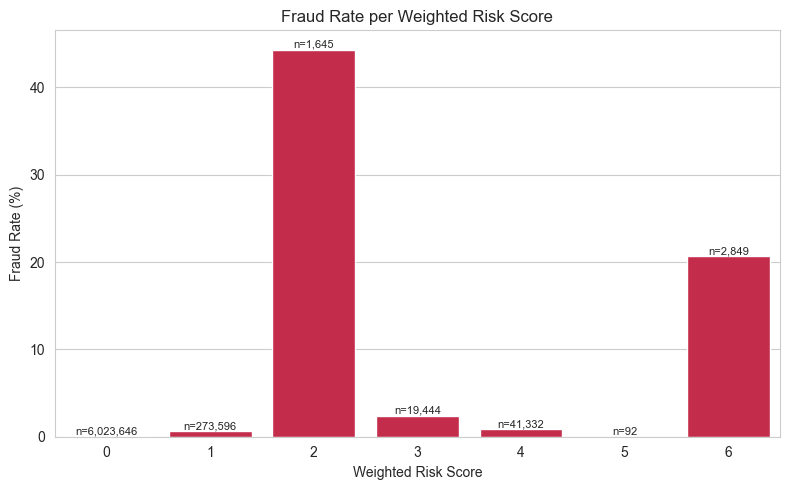

,risk_score,fraud_rate,transactions,fraud_count,fraud_rate_pct
0,0,0.000721,6023646,4342,0.072083
1,1,0.006203,273596,1697,0.620258
2,2,0.443161,1645,729,44.316109
3,3,0.024223,19444,471,2.422341
4,4,0.008904,41332,368,0.890351
5,5,0.000000,92,0,0.000000
6,6,0.207090,2849,590,20.709021


In [44]:
fraud_by_score = df.groupby("risk_score")["isFraud"].agg(["mean", "count", "sum"]).reset_index()
fraud_by_score = fraud_by_score.rename(columns={"mean": "fraud_rate", "count": "transactions", "sum": "fraud_count"})
fraud_by_score["fraud_rate_pct"] = fraud_by_score["fraud_rate"] * 100

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=fraud_by_score, x="risk_score", y="fraud_rate_pct", ax=ax, color="crimson")
ax.set_ylabel("Fraud Rate (%)")
ax.set_xlabel("Weighted Risk Score")
ax.set_title("Fraud Rate per Weighted Risk Score")
for i, row in fraud_by_score.iterrows():
    ax.text(i, row["fraud_rate_pct"], f"n={int(row['transactions']):,}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

fraud_by_score

## 10. Overlap Antarmetode dan Fraud vs High Risk

Visualisasi ini menunjukkan metode mana yang sering saling sepakat dan apakah kelompok high risk didominasi oleh fraud atau non-fraud. Bagian ini penting karena anomaly detection tidak selalu sama dengan fraud detection.

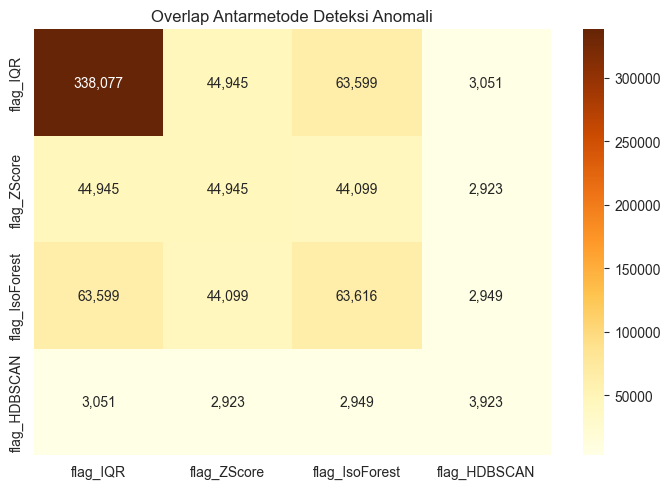

,flag_IQR,flag_ZScore,flag_IsoForest,flag_HDBSCAN
flag_IQR,338077.0,44945.0,63599.0,3051.0
flag_ZScore,44945.0,44945.0,44099.0,2923.0
flag_IsoForest,63599.0,44099.0,63616.0,2949.0
flag_HDBSCAN,3051.0,2923.0,2949.0,3923.0


In [45]:
flag_cols = ["flag_IQR", "flag_ZScore", "flag_IsoForest", "flag_HDBSCAN"]
method_overlap = pd.DataFrame(index=flag_cols, columns=flag_cols, dtype=int)
for row_col in flag_cols:
    for col_col in flag_cols:
        method_overlap.loc[row_col, col_col] = int(((df[row_col] == 1) & (df[col_col] == 1)).sum())

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(method_overlap, annot=True, fmt=",.0f", cmap="YlOrBr", ax=ax)
ax.set_title("Overlap Antarmetode Deteksi Anomali")
plt.tight_layout()
plt.show()

method_overlap

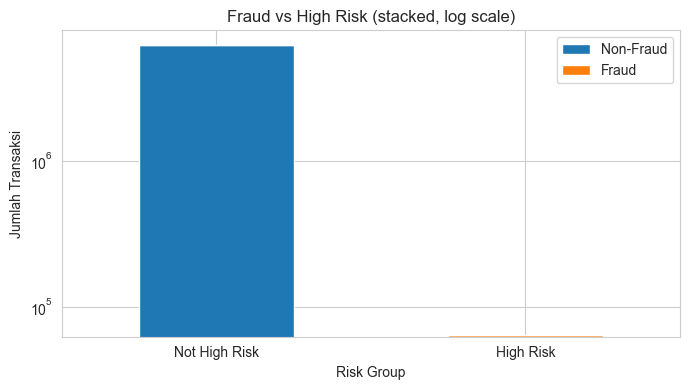

,Non-Fraud,Fraud
Not High Risk,6292119,6768
High Risk,62288,1429


In [46]:
fraud_highrisk = pd.crosstab(df["high_risk"], df["isFraud"])
fraud_highrisk.index = ["Not High Risk", "High Risk"]
fraud_highrisk.columns = ["Non-Fraud", "Fraud"]

fraud_highrisk.plot(kind="bar", stacked=True, figsize=(7, 4))
plt.yscale("log")
plt.title("Fraud vs High Risk (stacked, log scale)")
plt.xlabel("Risk Group")
plt.ylabel("Jumlah Transaksi")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

fraud_highrisk

## 11. Cross-Reference dengan Customer Segmentation Phase 2

K-Means tetap dipakai sebagai acuan segmentasi utama di Phase 2 karena jumlah cluster-nya stabil dan dipilih berdasarkan Elbow Method serta Approximate Silhouette Score. Pada Phase 4, cluster K-Means tidak dijadikan flag risiko langsung, tetapi dipakai untuk membaca segmen pelanggan/transaksi mana yang paling banyak memuat fraud dan high-risk transaction.

In [47]:
if "cluster_kmeans" in df.columns:
    cluster_summary = (
        df.groupby("cluster_kmeans")
        .agg(
            transactions=("isFraud", "size"),
            fraud_count=("isFraud", "sum"),
            fraud_rate=("isFraud", "mean"),
            avg_risk_score=("risk_score", "mean"),
            high_risk_count=("high_risk", "sum"),
            critical_count=("critical_risk", "sum"),
        )
        .reset_index()
    )
    cluster_summary["fraud_rate_pct"] = cluster_summary["fraud_rate"] * 100
    cluster_summary["high_risk_rate_pct"] = cluster_summary["high_risk_count"] / cluster_summary["transactions"] * 100
    display(cluster_summary.sort_values(["fraud_rate", "avg_risk_score"], ascending=False))
else:
    print("Kolom cluster_kmeans tidak ditemukan.")

,cluster_kmeans,transactions,fraud_count,fraud_rate,avg_risk_score,high_risk_count,critical_count,fraud_rate_pct,high_risk_rate_pct
2,2,391249,1032,0.002638,0.039670,2790,503,0.263771,0.713101
1,1,5880042,7065,0.001202,0.083410,58726,1322,0.120152,0.998734
3,3,89665,100,0.001115,0.049629,897,134,0.111526,1.000390
0,0,1648,0,0.000000,4.656553,1304,982,0.000000,79.126214


## 12. Pilih dan Ekspor Top Suspicious Transactions

Output akhir Phase 4 sekarang tidak hanya memuat transaksi mencurigakan, tetapi juga risk_score, risk_level, anomaly_type, investigation_category, dan anomaly_reason. Kolom-kolom ini dapat langsung dipakai di Phase 5 untuk dashboard dan laporan interpretatif.

In [51]:
def select_top_anomalies(df, top_n=20000):
    sort_cols = ["risk_score", "risk_indicator_count", "flag_BalanceMismatch", "amount"]
    sort_cols = [col for col in sort_cols if col in df.columns]
    top_df = df.sort_values(by=sort_cols, ascending=[False] * len(sort_cols)).head(top_n)

    print(f"Top suspicious transactions selected : {len(top_df):,}")
    print(f"Fraud rate in the subset          : {top_df['isFraud'].mean()*100:.2f}%")
    print("Investigation category dalam top suspicious:")
    print(top_df["investigation_category"].value_counts())

    return top_df

top_df = select_top_anomalies(df)

display_cols = [
    "amount", "origError", "destError",
    "flag_IQR", "flag_ZScore", "flag_IsoForest", "flag_HDBSCAN", "flag_BalanceMismatch",
    "risk_indicator_count", "risk_score", "risk_level", "anomaly_type", "investigation_category", "anomaly_reason", "isFraud"
]
top_df[display_cols].head(10)

Top suspicious transactions selected : 20,000
Fraud rate in the subset          : 2.99%
Investigation category dalam top suspicious:
investigation_category
Possible Data Quality Issue    17051
Potential Fraud                 2949
Normal / Low Concern               0
Potential Risk / Monitor           0
Rare Legitimate Transaction        0
Name: count, dtype: int64


,amount,origError,destError,flag_IQR,flag_ZScore,flag_IsoForest,flag_HDBSCAN,flag_BalanceMismatch,risk_indicator_count,risk_score,risk_level,anomaly_type,investigation_category,anomaly_reason,isFraud
3686581,472.890320,374.469025,-0.117997,1,1,1,1,1,4,6,Critical,Multiple Indicators,Potential Fraud,High amount anomaly by IQR; Extreme amount ano...,0
4060595,377.555084,298.980713,-0.117997,1,1,1,1,1,4,6,Critical,Multiple Indicators,Potential Fraud,High amount anomaly by IQR; Extreme amount ano...,0
4146394,363.983276,288.234283,-0.117997,1,1,1,1,1,4,6,Critical,Multiple Indicators,Potential Fraud,High amount anomaly by IQR; Extreme amount ano...,0
3946917,357.400909,283.022217,-0.117997,1,1,1,1,1,4,6,Critical,Multiple Indicators,Potential Fraud,High amount anomaly by IQR; Extreme amount ano...,0
3911953,354.588196,280.795044,-0.117997,1,1,1,1,1,4,6,Critical,Multiple Indicators,Potential Fraud,High amount anomaly by IQR; Extreme amount ano...,0
3937149,345.185974,273.350189,-0.117997,1,1,1,1,1,4,6,Critical,Multiple Indicators,Potential Fraud,High amount anomaly by IQR; Extreme amount ano...,0
4105335,341.400146,270.352509,-0.117997,1,1,1,1,1,4,6,Critical,Multiple Indicators,Potential Fraud,High amount anomaly by IQR; Extreme amount ano...,0
3892526,328.464111,260.109497,831.042847,1,1,1,1,1,4,6,Critical,Multiple Indicators,Potential Fraud,High amount anomaly by IQR; Extreme amount ano...,0
3991635,326.485657,258.542908,-0.117997,1,1,1,1,1,4,6,Critical,Multiple Indicators,Potential Fraud,High amount anomaly by IQR; Extreme amount ano...,0
4143798,323.653809,256.300598,-0.117997,1,1,1,1,1,4,6,Critical,Multiple Indicators,Potential Fraud,High amount anomaly by IQR; Extreme amount ano...,0


In [53]:
type_cols = [c for c in top_df.columns if c.startswith("type_")]
if type_cols:
    type_breakdown = top_df[type_cols].sum().sort_values(ascending=False)
    print("Transaction breakdown top-suspicious based on type:")
    print(type_breakdown)

Transaction breakdown top-suspicious based on type:
type_TRANSFER    19931
type_CASH_IN        49
type_CASH_OUT       20
type_DEBIT           0
type_PAYMENT         0
dtype: int64


In [54]:
output_dir = "../datasets/phase_4"
os.makedirs(output_dir, exist_ok=True)

# Export utama untuk Phase 5/dashboard
top_output_path = os.path.join(output_dir, "paysim-suspicious-transactions.parquet")
top_df.to_parquet(top_output_path, index=False)
print(f"Exported: {top_output_path}")

# Export ringkasan tambahan
risk_summary.to_csv(os.path.join(output_dir, "risk_summary.csv"), index=False)
anomaly_type_summary.to_csv(os.path.join(output_dir, "anomaly_type_summary.csv"), index=False)
investigation_summary.to_csv(os.path.join(output_dir, "investigation_summary.csv"), index=False)
fraud_by_score.to_csv(os.path.join(output_dir, "fraud_by_score.csv"), index=False)
fraud_metrics.to_csv(os.path.join(output_dir, "fraud_validation_metrics.csv"), index=False)
method_overlap.reset_index().rename(columns={"index": "method"}).to_csv(os.path.join(output_dir, "method_overlap.csv"), index=False)

if "cluster_summary" in globals():
    cluster_summary.to_csv(os.path.join(output_dir, "cluster_kmeans_risk_summary.csv"), index=False)

print("Exported summary CSV files to:", output_dir)

Exported: ../datasets/phase_4\paysim-suspicious-transactions.parquet
Exported summary CSV files to: ../datasets/phase_4
